# Module1 : End Project

### As a culminating project, you'll be working with a dataset from ABC company, consisting of 458 rows and 9 columns. The company requires a comprehensive report detailing information about their employees across various teams. Your tasks include preprocessing the dataset, analyzing the data, and presenting your findings graphically. Here's a breakdown of what you need to do: Preprocessing:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Read the Excel file (specifying the sheet is ideal as CSV only supports one sheet)
df = pd.read_excel("ABC Company.xlsx", sheet_name="Sheet1")

# Convert and save to CSV without including row index numbers
df.to_csv("ABC.csv", index=False)

In [4]:
df=df.reset_index().head(400)
df


,index,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...,...
395,395,Jusuf Nurkic,Denver Nuggets,23,C,21,7-0,280,NaN,1842000.0
396,396,JaKarr Sampson,Denver Nuggets,9,SG,23,2023-09-06 00:00:00,214,St. John's,258489.0
397,397,Axel Toupane,Denver Nuggets,6,SG,23,2023-07-06 00:00:00,210,NaN,NaN
398,398,Nemanja Bjelica,Minnesota Timberwolves,88,PF,28,2023-10-06 00:00:00,240,NaN,3950001.0


### ● Correct the data in the "height" column by replacing it with random
numbers between 150 and 180. Ensure data consistency and integrity
before proceeding with analysis. (1 mark)

In [5]:
import random

In [6]:
df['Height'] = [random.randint(150, 180) for _ in range(len(df))]

In [7]:
df

,index,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,0,Avery Bradley,Boston Celtics,0,PG,25,158,180,Texas,7730337.0
1,1,Jae Crowder,Boston Celtics,99,SF,25,165,235,Marquette,6796117.0
2,2,John Holland,Boston Celtics,30,SG,27,174,205,Boston University,NaN
3,3,R.J. Hunter,Boston Celtics,28,SG,22,162,185,Georgia State,1148640.0
4,4,Jonas Jerebko,Boston Celtics,8,PF,29,156,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...,...
395,395,Jusuf Nurkic,Denver Nuggets,23,C,21,164,280,NaN,1842000.0
396,396,JaKarr Sampson,Denver Nuggets,9,SG,23,178,214,St. John's,258489.0
397,397,Axel Toupane,Denver Nuggets,6,SG,23,180,210,NaN,NaN
398,398,Nemanja Bjelica,Minnesota Timberwolves,88,PF,28,151,240,NaN,3950001.0


### Analysis Tasks: ● Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees. (2 marks) ●

In [8]:
# Calculate employee count per team
team_counts = df['Team'].value_counts()

In [9]:
# Calculate percentage split relative to total employees
team_percentage = (df['Team'].value_counts(normalize=True) * 100).round(2)

In [10]:
# Combine into a summary DataFrame
distribution_df = pd.DataFrame(
    {'Employee Count': team_counts, 'Percentage (%)': team_percentage}
)

print(distribution_df)

                        Employee Count  Percentage (%)
Team                                                  
New Orleans Pelicans                19            4.75
Memphis Grizzlies                   18            4.50
Milwaukee Bucks                     16            4.00
New York Knicks                     16            4.00
Boston Celtics                      15            3.75
Denver Nuggets                      15            3.75
Washington Wizards                  15            3.75
Miami Heat                          15            3.75
Charlotte Hornets                   15            3.75
Atlanta Hawks                       15            3.75
San Antonio Spurs                   15            3.75
Houston Rockets                     15            3.75
Dallas Mavericks                    15            3.75
Indiana Pacers                      15            3.75
Brooklyn Nets                       15            3.75
Detroit Pistons                     15            3.75
Cleveland 

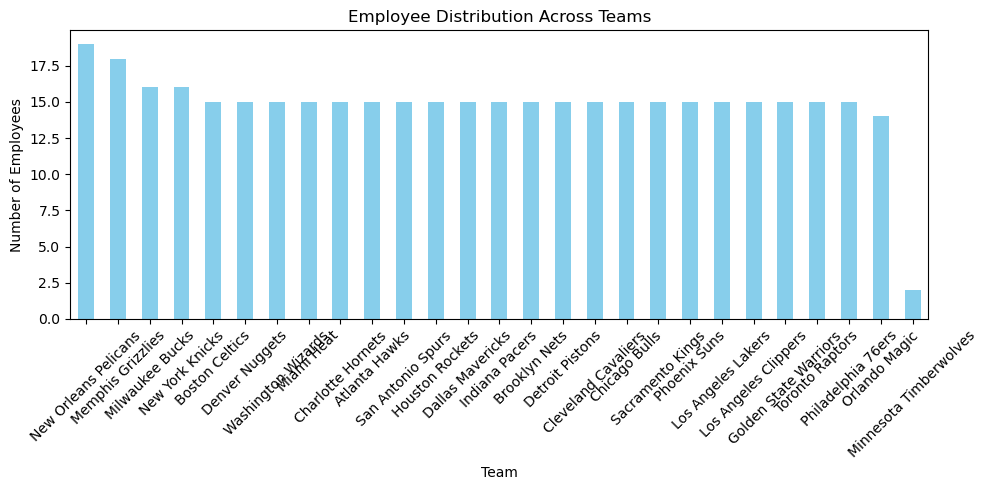

In [45]:
# Graph 1: Team Distribution Bar Chart
plt.figure(figsize=(10, 5))
team_counts.plot(kind='bar', color='skyblue')
plt.title('Employee Distribution Across Teams')
plt.xlabel('Team')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### ● Segregate employees based on their positions within the company. (2 marks)

In [48]:
# --- Task 2: Segregate employees based on their positions ---
position_grouped = df.groupby('Position')['Name'].apply(list)
position_counts = df['Position'].value_counts()
print('\n--- Position Counts ---')
print(position_counts)


--- Position Counts ---
Position
SG    90
PF    88
PG    81
SF    74
C     67
Name: count, dtype: int64


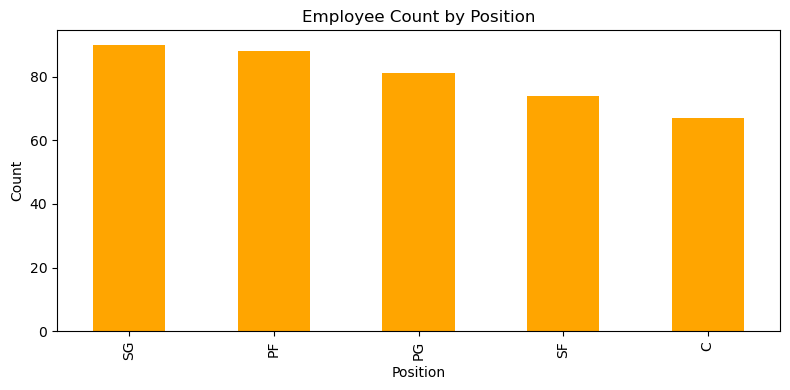

In [49]:
# Graph 2: Position Segregation Bar Chart
plt.figure(figsize=(8, 4))
position_counts.plot(kind='bar', color='orange')
plt.title('Employee Count by Position')
plt.xlabel('Position')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### ● Identify the predominant age group among employees. (2 marks)


In [52]:
# --- Task 3: Identify the predominant age group ---
# Creating age bins (e.g., 20-24, 25-29, 30-34, etc.)
bins = [18, 22, 26, 30, 35, 40]
labels = ['19-22', '23-26', '27-30', '31-35', '36-40']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_group_counts = df['Age_Group'].value_counts()
print('\n--- Age Group Distribution ---')
print(age_group_counts)


--- Age Group Distribution ---
Age_Group
23-26    139
27-30    120
31-35     65
19-22     56
36-40     20
Name: count, dtype: int64


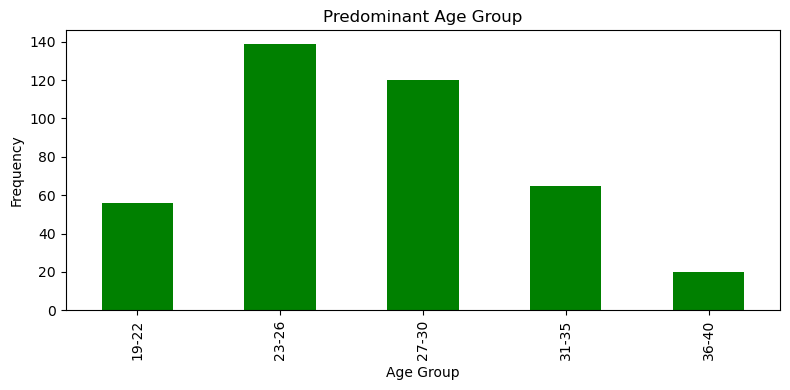

In [53]:
# Graph 3: Age Group Histogram/Bar Chart
plt.figure(figsize=(8, 4))
age_group_counts.sort_index().plot(kind='bar', color='green')
plt.title('Predominant Age Group')
plt.xlabel('Age Group')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### ● Discover which team and position have the highest salary expenditure. (2
marks)

In [54]:
# 4. Team and position with the highest salary expenditure
team_salary = df.groupby('Team')['Salary'].sum()
position_salary = df.groupby('Position')['Salary'].sum()

highest_salary_team = team_salary.idxmax()
highest_salary_position = position_salary.idxmax()

print('Team with highest salary expenditure:', highest_salary_team)
print('Position with highest salary expenditure:', highest_salary_position)

Team with highest salary expenditure: Cleveland Cavaliers
Position with highest salary expenditure: C


### ● Investigate if there's any correlation between age and salary, and epresent it visually. (2 marks)


Correlation between Age and Salary: 0.2264


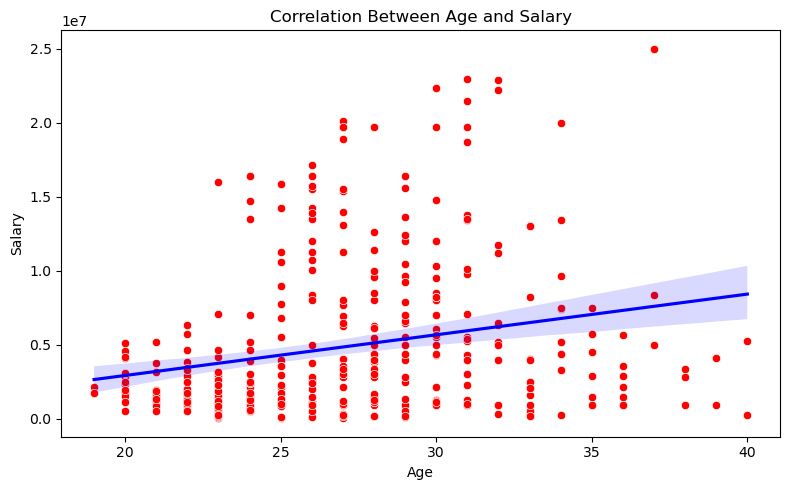

In [55]:
# --- Task 5: Correlation between age and salary ---
correlation = df['Age'].corr(df['Salary'])
print(f'\nCorrelation between Age and Salary: {correlation:.4f}')

# Graph 5: Scatter Plot with Regression Line
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Salary', color='red')
sns.regplot(data=df, x='Age', y='Salary', scatter=False, color='blue')
plt.title('Correlation Between Age and Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()